# Activation Function Comparison (MNIST) – Project Abstract

 **Objective**

The goal of this project is to understand and compare the performance of different activation functions in a neural network using the MNIST handwritten digit classification dataset.

📚 **Dataset Used – MNIST**

MNIST is a popular benchmark dataset containing handwritten digits from 0 to 9.

Dataset Details:

- 70,000 grayscale images

- Training images: 60,000

- Testing images: 10,000

- Image size: 28 × 28 pixels

Each image is converted into a 784-length vector before being fed into the neural network.


⚙️ **Data Preprocessing
♻️ Normalization
🔎 Flattening Images**


# **Activation Functions Tested**

The project compares the following activation functions:

- ReLU

- Sigmoid

- Tanh

- Leaky ReLU

- GELU

- Swish

🏛️ **Model Architecture**

The neural network consists of:
>Input Layer → 784 neurons

>Hidden Layer 1 → 256 neurons

>Hidden Layer 2 → 128 neurons

>Output Layer → 10 neurons (Softmax)

The hidden layers use the selected activation function, while the output layer uses Softmax for classification.

**What This Program Does**

✔ Loads MNIST dataset

✔ Builds SAME model architecture

✔ Changes only activation

✔ Trains each model

✔ Compares performance

✔ Plots validation accuracy



**This Experiment helps to understand:**

- Role of activation functions in neural networks

- Impact of activation functions on training behaviour

- Model benchmarking and evaluation techniques

- Practical deep learning experimentation

# Import Libraies

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import time

# Load MNIST Dataset


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
**Why Do We Normalize Pixel Values?**

---

- In the MNIST dataset, each image is made of pixels whose values range from 0 to 255.

- 0 → Represents black

- 255 → Represents white

- Values between 0 and 255 represent different shades of gray.

Neural networks perform better when input values are kept within a small and consistent range. Large input values can slow down training and make optimization unstable.

To solve this, we normalize the pixel values by dividing them by 255:


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

**What Normalization Does**

- Converts pixel values from [0, 255] → [0, 1]

- Helps the neural network train faster  |  Improves numerical stability

- Helps gradient descent converge more efficiently | Prevents some activation functions from saturating

| Original Pixel Value | After Normalization |
| -------------------- | ------------------- |
| 0                    | 0.0                 |
| 128                  | 0.50                |
| 255                  | 1.0                 |


# Flatten images
**Why Do We Flatten the Images?**

---

MNIST images are originally in 28 × 28 pixel format (2D).
However, a fully connected neural network expects input as a 1D vector.

So, we convert each 28 × 28 image into a single row of 784 pixels (28 × 28 = 784).

In [4]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

**What This Does**

- Converts image from 2D → 1D

- Makes data compatible with Dense (fully connected) layers

- -1 automatically adjusts the number of images

# Custom Swish Activation

Swish is a modern activation function that improves neural network performance by combining linear and non-linear behaviour.

The Swish activation function is mathematically defined as:

$$
\text{Swish}(x) = x \cdot \sigma(x)
$$

where the **Sigmoid function** is:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$


In [5]:
def swish(x):
    return x * tf.nn.sigmoid(x)


#### Sigmoid Function

The sigmoid function maps any real number into a value between **0 and 1**.

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

---

#### Swish Function

Swish multiplies the input value with the sigmoid output:

$$
f(x) = x \cdot \frac{1}{1 + e^{-x}}
$$

---

### Derivative of Swish

Using the product rule:

$$
f(x) = x \sigma(x)
$$

Derivative:

$$
f'(x) = \sigma(x) + x \cdot \sigma(x)(1 - \sigma(x))
$$

---

**Why Swish is Useful**

- Provides smooth gradient flow  
- Helps deep neural networks train efficiently  
- Allows small negative values instead of blocking them completely  

# **Model Builder Function**
This function creates and compiles a neural network model using different activation functions. It allows us to test and compare how each activation function affects model performance.

**What This Function Does**

---

- Selects the activation function based on the input name

- Builds a fully connected neural network

- Uses two hidden layers (256 and 128 neurons)

- Uses Softmax in the output layer for digit classification

- Compiles the model using the Adam optimizer and cross-entropy loss

In [6]:
%%time

def build_model(activation_name):

    if activation_name == "leaky_relu":
        activation_layer = layers.LeakyReLU()
    elif activation_name == "gelu":
        activation_layer = tf.keras.activations.gelu
    elif activation_name == "swish":
        activation_layer = swish
    else:
        activation_layer = activation_name

    model = models.Sequential([
        layers.Dense(256, input_shape=(784,)),
        layers.Activation(activation_layer),

        layers.Dense(128),
        layers.Activation(activation_layer),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    return model

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 7.39 µs


# **Activation Functions to Test**

This section defines the list of activation functions that will be tested in the experiment. Each activation function will be used to train the same neural network model to compare their performance.

Purpose

- Stores different activation functions to evaluate

- Helps automate training for multiple activations

- Ensures fair comparison using the same model structure

In [7]:
activations = ["relu","sigmoid","tanh","leaky_relu","gelu","swish"]

history_dict = {}
test_results = {}

**Result Storage**

*history_dict* → Stores training and validation performance for each activation function

*test_results* → Stores final test accuracy for comparison

# Train Models
This section trains the neural network using each activation function defined earlier. It allows us to compare how different activation functions affect model performance.

**What This Loop Does**

- Iterates through each activation function in the list.

- Builds a new model using the selected activation.

---

**Model Training**

- Each activation function is trained using the same model architecture

- Trains the model using training data.

- *epochs*  = 5 → Model trains 5 times over dataset.

- *batch_size* = 128 → Processes 128 samples at once.

- *validation_split* = 0.2 → Uses 20% of training data for validation.
- Validation dataset used to monitor performance

- Stores training performance (accuracy & loss).
- Final evaluation performed using test dataset


---

**Model Evaluation**

- Tests model performance using unseen test data.

- Returns test loss and accuracy.

---

**Epoch**

One full pass through entire training dataset

In [8]:
%%time
for act in activations:
    print(f"\nTraining with {act} activation")

    model = build_model(act)

    history = model.fit(x_train, y_train,epochs=5,batch_size=128,validation_split=0.2,verbose=1)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    history_dict[act] = history.history
    test_results[act] = test_acc



Training with relu activation


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8387 - loss: 0.5597 - val_accuracy: 0.9589 - val_loss: 0.1450
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9635 - loss: 0.1233 - val_accuracy: 0.9674 - val_loss: 0.1131
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9778 - loss: 0.0757 - val_accuracy: 0.9711 - val_loss: 0.0985
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9840 - loss: 0.0552 - val_accuracy: 0.9746 - val_loss: 0.0867
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9887 - loss: 0.0366 - val_accuracy: 0.9750 - val_loss: 0.0839

Training with sigmoid activation
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6492 - loss: 1.2389 - val_accuracy: 0.9203 - val_loss: 0.2887
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9201 - loss: 0.2785 - val_accuracy: 0.9379 - val_loss: 0.2143
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9390 - l

**Activation Function Training Results Explanation**

This output shows how different activation functions performed while training a neural network on the MNIST digit classification dataset.


----

**🟠ReLU Activation Function**

Final val_accuracy → 97.50 %
- Fast learning and stable convergence
- Performs very well in deep networks
→ Strong baseline activation

---
**🔵 Sigmoid Activation Function**

Final Validation Accuracy → 96.24%

- Slower training
- Higher loss compared to others
- Suffers from vanishing gradient problem → Performs worst among tested activations
---

🟢 Tanh Activation

Final Validation Accuracy → 97.17%
- Better than sigmoid
- Balanced output between -1 and 1 → Good stability Good traditional activation

---
🟡 Leaky ReLU Activation

Final Validation Accuracy → 96.93%
- Solves dead neuron problem of ReLU
- Slightly lower performance than ReLU → Good alternative to ReLU

---

🟣 GELU Activation

Final Validation Accuracy → 97.53%
- Smooth activation curve
- Used in Transformer models and LLMs
- Shows strong and stable performance → One of the best performing activations

---

🟠 Swish Activation

Final Validation Accuracy → 97.66%
- Smooth gradient flow
- Often outperforms ReLU
- Shows best performance in this experiment → Highest accuracy among tested functions

Training Performance Summary Table
| Activation | Validation Accuracy |
| ---------- | ------------------- |
| ReLU       | 97.50%              |
| Sigmoid    | 96.24%              |
| Tanh       | 97.17%              |
| Leaky ReLU | 96.93%              |
| GELU       | 97.53%              |
| Swish      | **97.66% (Best)** |


# Plot Accuracy Comparison


This section visualizes and compares the validation accuracy of different activation functions across training epochs. It helps to understand how each activation function performs during model learning.

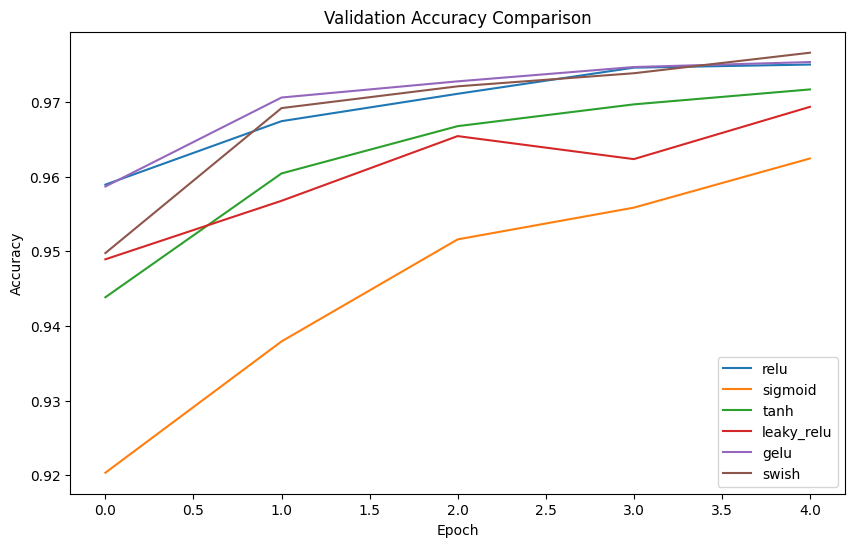

In [9]:
plt.figure(figsize=(10,6))

for act in activations:
    plt.plot(history_dict[act]["val_accuracy"], label=act)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

- X-axis shows number of training epochs
- Y-axis shows validation accuracy

# Loss Graph

This section plots the validation loss of the model during training. Loss measures how far the model’s predictions are from the actual values. Lower loss indicates better model performance

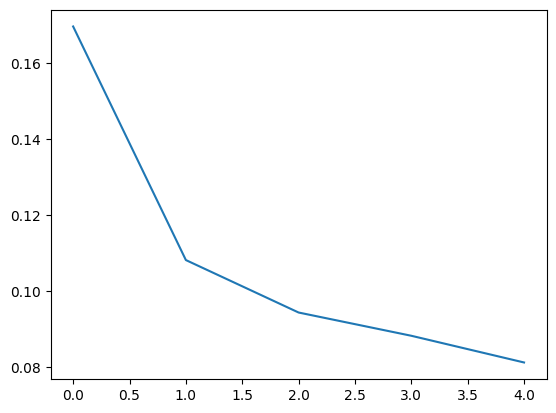

In [10]:
plt.plot(history_dict[act]["val_loss"])

**Why Loss Graph is Important**

- Shows whether model error is decreasing
- Helps detect overfitting or underfitting
- Helps compare learning stability between activation functions

📌 Interpretation

📉 Decreasing Loss → Model is improving

📈 Increasing Loss → Model may be overfitting or unstable

⚖️ Stable Low Loss → Good model performance

# Print Final Test Accuracy


This section displays the final accuracy of each activation function when evaluated on the test dataset. The test dataset contains unseen data, which helps measure how well the model generalizes to new inputs.

In [11]:
print("\nFinal Test Accuracy:")
for act, acc in test_results.items():
    print(f"{act}: {acc:.4f}")


Final Test Accuracy:
relu: 0.9772
sigmoid: 0.9617
tanh: 0.9735
leaky_relu: 0.9722
gelu: 0.9791
swish: 0.9759


These values represent the percentage of correctly classified digits by each activation function.

**Final Test Accuracy**
| Activation Function | Test Accuracy |
| ------------------- | ------------- |
| GELU                | **97.91**% ✔   |
| ReLU                | 97.72%        |
| Swish               | 97.59%        |
| Tanh                | 97.35%        |
| Leaky ReLU          | 97.22%        |
| Sigmoid             | 96.17%        |

 ✔ GELU achieved the highest accuracy

- Provides smooth gradient flow , Often used in modern deep learning models

*ReLU and Swish performed very well*

- ReLU is computationally efficient , Swish improves smooth learning behaviour

*Sigmoid performed the worst*

- Suffers from vanishing gradient problem , Slower learning in deeper networks


# Predict using trained model
This section uses the trained neural network model to predict a digit from the test dataset. It also displays the model’s confidence level for each possible digit.

In [12]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


⬆ The model predicts probability scores for all test images.  Each prediction contains probabilities for digits 0 to 9.


**Choose random test sample**

In [13]:
index = np.random.randint(0, len(x_test))

⬆ Selects a random image from the test dataset.

**Predicted digit**

In [14]:
predicted_digit = np.argmax(predictions[index])

⬆ Finds the digit with the highest probability. argmax returns the index of the highest value. This becomes the predicted digit.

**Actual digit**

In [15]:
actual_digit = y_test[index]

In [16]:
print("Predicted Digit :", predicted_digit)
print("Actual Digit    :", actual_digit)

Predicted Digit : 9
Actual Digit    : 9


⬆  Retrieves the true label of the selected image. Used to check prediction accuracy.

**Show Probability Scores**

In [17]:
print("\nPrediction Probabilities:")
print(predictions[index])


Prediction Probabilities:
[1.5441868e-08 7.1391615e-11 1.8935619e-08 2.5648926e-05 1.5501308e-07
 2.1288886e-07 1.2188763e-11 9.3801344e-07 5.5456680e-06 9.9996740e-01]


Each value represents the model’s confidence that the image belongs to a particular digit.

**Display Image**

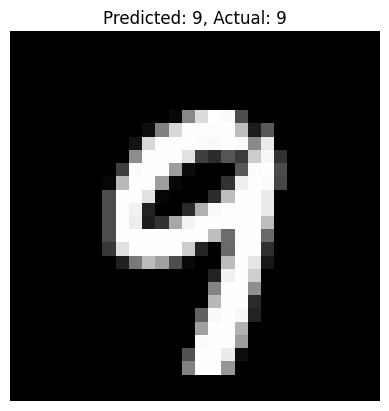

In [18]:
plt.imshow(x_test[index].reshape(28,28), cmap="gray")
plt.title(f"Predicted: {predicted_digit}, Actual: {actual_digit}")
plt.axis("off")
plt.show()


0.97 means model is 97% confident it's digit 9

*Print Model Accuracy*

In [19]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

accuracy = np.mean(predicted_labels == y_test)

print("Model Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model Accuracy: 0.9759


Model strongly believes the image represents digit 9

Confidence = 97%

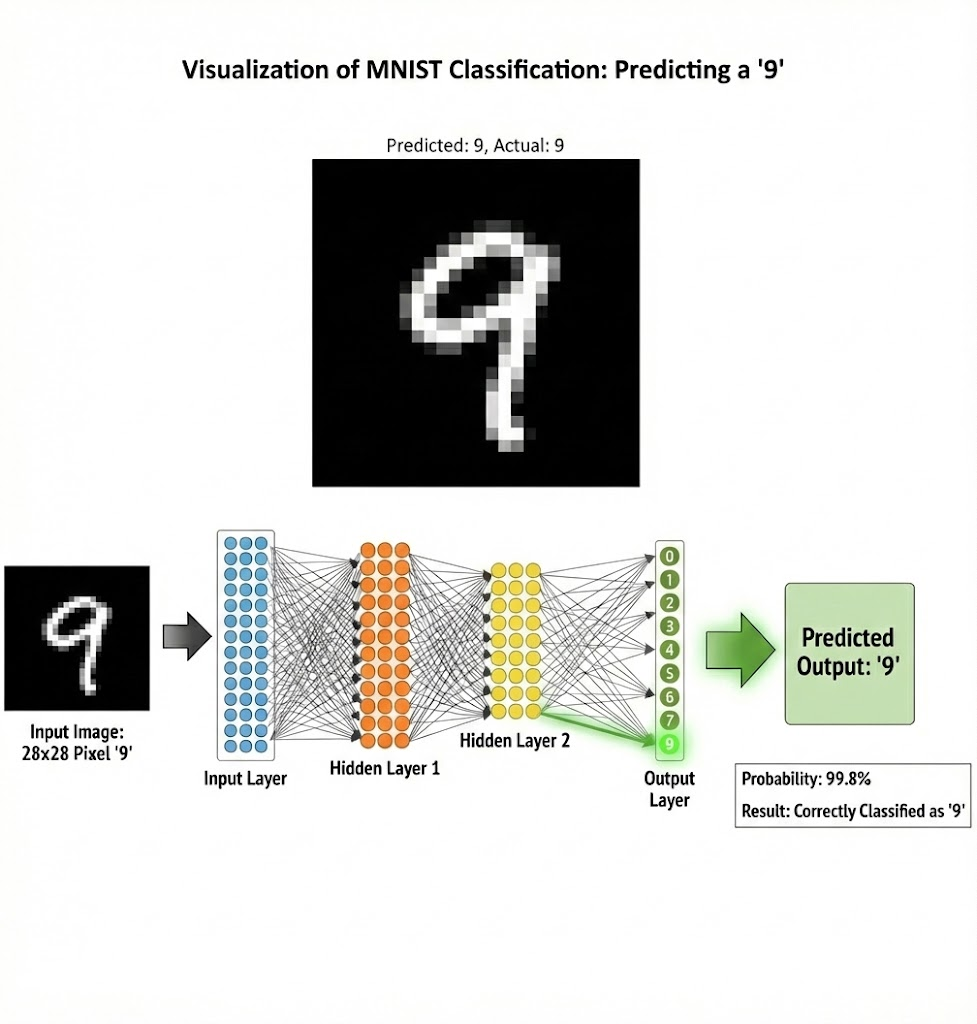

# To Print Multiple Predictions

This section displays predictions for multiple test images instead of a single sample. It helps visually verify how well the model performs on different inputs.

Sample 0
Predicted: 7
Actual   : 7
------------------


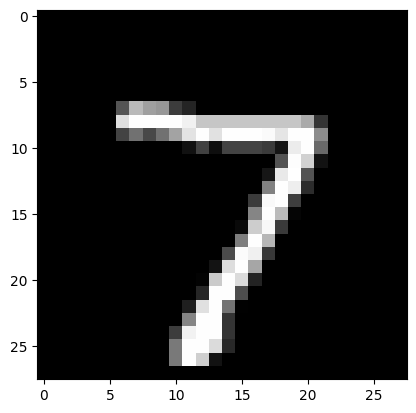

Sample 1
Predicted: 2
Actual   : 2
------------------


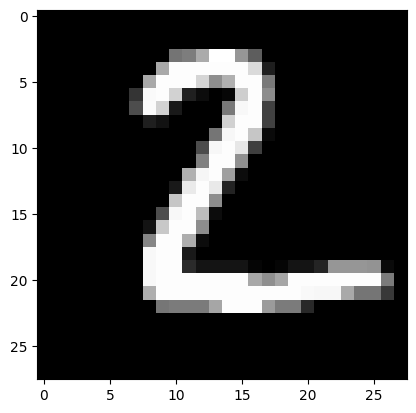

Sample 2
Predicted: 1
Actual   : 1
------------------


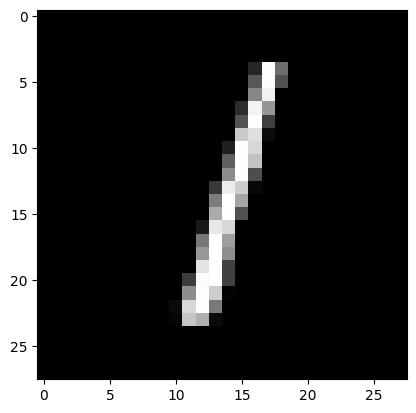

Sample 3
Predicted: 0
Actual   : 0
------------------


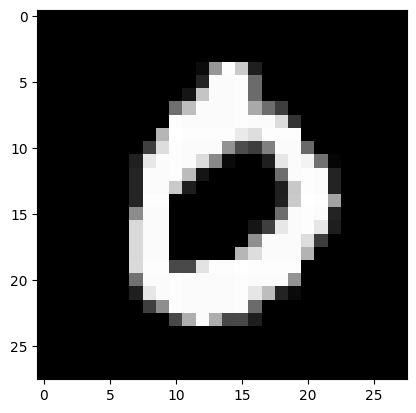

Sample 4
Predicted: 4
Actual   : 4
------------------


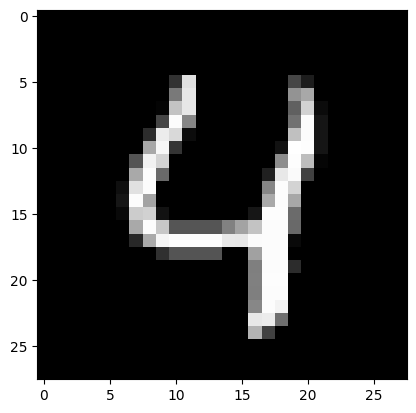

In [20]:
for i in range(5):

    predicted = np.argmax(predictions[i])
    actual = y_test[i]

    print(f"Sample {i}")
    print("Predicted:", predicted)
    print("Actual   :", actual)
    print("------------------")

    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.show()
